In [5]:
!pip install scikit-image


  Using cached imageio-2.37.0-py3-none-any.whl.metadata (5.2 kB)
  Using cached tifffile-2025.3.30-py3-none-any.whl.metadata (32 kB)
  Using cached lazy_loader-0.4-py3-none-any.whl.metadata (7.6 kB)
   ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
    --------------------------------------- 0.3/12.8 MB ? eta -:--:--
   -- ------------------------------------- 0.8/12.8 MB 1.7 MB/s eta 0:00:08
   --- ------------------------------------ 1.0/12.8 MB 1.9 MB/s eta 0:00:07
   ---- ----------------------------------- 1.6/12.8 MB 1.8 MB/s eta 0:00:07
   ------- -------------------------------- 2.4/12.8 MB 2.1 MB/s eta 0:00:05
   ----------- ---------------------------- 3.7/12.8 MB 2.8 MB/s eta 0:00:04
   ---------------- ----------------------- 5.2/12.8 MB 3.5 MB/s eta 0:00:03
   ------------------- -------------------- 6.3/12.8 MB 3.6 MB/s eta 0:00:02
   -------------------------- ------------- 8.4/12.8

In [6]:
import torchvision.datasets as datasets
import matplotlib.pyplot as plt
import numpy as np
from skimage.feature import hog
from tqdm import tqdm

##Loading train and test data


In [7]:
train_data = datasets.CIFAR10(root="./data",train=True,download=True,transform=None)

100%|██████████| 170M/170M [00:27<00:00, 6.14MB/s] 


In [8]:
test_data = datasets.CIFAR10(root="./data",train=False,download=True,transform=None)

## Function to read .tar files (source : https://www.cs.toronto.edu/~kriz/cifar.html)

In [13]:
import os
import tarfile
import urllib.request

cifar_path = '/content/data'
cifar_url = 'https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz'
cifar_tar_path = os.path.join(cifar_path, 'cifar-10-python.tar.gz')

# Create directory if it doesn't exist
os.makedirs(cifar_path, exist_ok=True)

# Download if not already downloaded
if not os.path.exists(cifar_tar_path):
    print("Downloading CIFAR-10...")
    urllib.request.urlretrieve(cifar_url, cifar_tar_path)

# Extract
print("Extracting CIFAR-10...")
with tarfile.open(cifar_tar_path, 'r:gz') as tar:
    tar.extractall(path=cifar_path)

print("Done!")


Extracting CIFAR-10...
Done!


In [14]:
def unpickle(file):
    import pickle
    with open(file, 'rb') as fo:
        dict = pickle.load(fo, encoding='bytes')
    return dict

##batch 1 to 5 are train data and test_batch is test data

In [15]:
batch1 = unpickle("/content/data/cifar-10-batches-py/data_batch_1")
batch2 = unpickle("/content/data/cifar-10-batches-py/data_batch_2")
batch3 = unpickle("/content/data/cifar-10-batches-py/data_batch_3")
batch4 = unpickle("/content/data/cifar-10-batches-py/data_batch_4")
batch5 = unpickle("/content/data/cifar-10-batches-py/data_batch_5")
test_batch = unpickle("/content/data/cifar-10-batches-py/test_batch")

## Checking what is in every batch

In [16]:
type(batch1),len(batch1)

(dict, 4)

In [17]:
batch1.keys()

dict_keys([b'batch_label', b'labels', b'data', b'filenames'])

In [18]:
print(batch1[b'batch_label'])


b'training batch 1 of 5'


In [19]:
print("we have 1000 images of 32x32x3 :",batch1[b'data'].shape)
print(batch1[b'data'])

we have 1000 images of 32x32x3 : (10000, 3072)
[[ 59  43  50 ... 140  84  72]
 [154 126 105 ... 139 142 144]
 [255 253 253 ...  83  83  84]
 ...
 [ 71  60  74 ...  68  69  68]
 [250 254 211 ... 215 255 254]
 [ 62  61  60 ... 130 130 131]]


##From above code it can be seen that Only important things are y = batch1[b'labels'] and X = batch1[b'data]

Checking X

In [20]:
image = batch1[b'data'][0]
image = image.reshape(3,32,32)
print(image)

[[[ 59  43  50 ... 158 152 148]
  [ 16   0  18 ... 123 119 122]
  [ 25  16  49 ... 118 120 109]
  ...
  [208 201 198 ... 160  56  53]
  [180 173 186 ... 184  97  83]
  [177 168 179 ... 216 151 123]]

 [[ 62  46  48 ... 132 125 124]
  [ 20   0   8 ...  88  83  87]
  [ 24   7  27 ...  84  84  73]
  ...
  [170 153 161 ... 133  31  34]
  [139 123 144 ... 148  62  53]
  [144 129 142 ... 184 118  92]]

 [[ 63  45  43 ... 108 102 103]
  [ 20   0   0 ...  55  50  57]
  [ 21   0   8 ...  50  50  42]
  ...
  [ 96  34  26 ...  70   7  20]
  [ 96  42  30 ...  94  34  34]
  [116  94  87 ... 140  84  72]]]


In [21]:
image = image.transpose(1,2,0)
print(image.shape)
image

(32, 32, 3)


array([[[ 59,  62,  63],
        [ 43,  46,  45],
        [ 50,  48,  43],
        ...,
        [158, 132, 108],
        [152, 125, 102],
        [148, 124, 103]],

       [[ 16,  20,  20],
        [  0,   0,   0],
        [ 18,   8,   0],
        ...,
        [123,  88,  55],
        [119,  83,  50],
        [122,  87,  57]],

       [[ 25,  24,  21],
        [ 16,   7,   0],
        [ 49,  27,   8],
        ...,
        [118,  84,  50],
        [120,  84,  50],
        [109,  73,  42]],

       ...,

       [[208, 170,  96],
        [201, 153,  34],
        [198, 161,  26],
        ...,
        [160, 133,  70],
        [ 56,  31,   7],
        [ 53,  34,  20]],

       [[180, 139,  96],
        [173, 123,  42],
        [186, 144,  30],
        ...,
        [184, 148,  94],
        [ 97,  62,  34],
        [ 83,  53,  34]],

       [[177, 144, 116],
        [168, 129,  94],
        [179, 142,  87],
        ...,
        [216, 184, 140],
        [151, 118,  84],
        [123,  92,  72]]

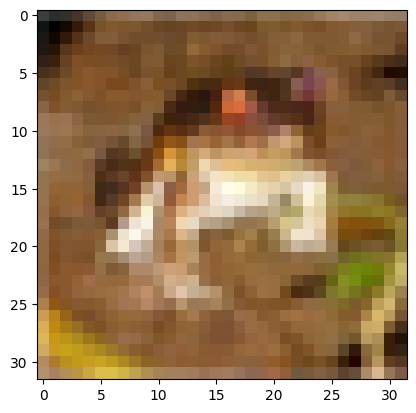

In [22]:
plt.imshow(image)

In [23]:
data = batch1[b'data']
data = data.reshape(len(data),3,32,32).transpose(0,2,3,1)
print(data.shape)

(10000, 32, 32, 3)


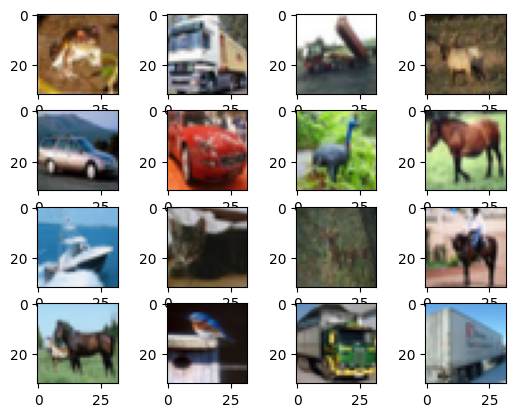

In [24]:
for i in range(16):
  plt.subplot(4,4,i+1)
  plt.imshow(data[i])
plt.show()

##Forming a tuple for training data and testing data of the form (X,y)

In [25]:
train_batch = [batch1,batch2,batch3,batch4,batch5]

In [26]:
train_data = []
for batch in train_batch:
  print("Keys of dictionary",batch.keys())
  print(batch[b'batch_label'])
  print("labels : ",batch[b'labels'])
  y_data = batch[b'labels']

  x_data = batch[b'data']
  x_data = x_data.reshape(len(x_data),3,32,32).transpose(0,2,3,1)
  print("shape of x_data : ",x_data.shape)

  for i in range(len(y_data)):
    train_data.append((x_data[i],y_data[i]))
  print()

Keys of dictionary dict_keys([b'batch_label', b'labels', b'data', b'filenames'])
b'training batch 1 of 5'
labels :  [6, 9, 9, 4, 1, 1, 2, 7, 8, 3, 4, 7, 7, 2, 9, 9, 9, 3, 2, 6, 4, 3, 6, 6, 2, 6, 3, 5, 4, 0, 0, 9, 1, 3, 4, 0, 3, 7, 3, 3, 5, 2, 2, 7, 1, 1, 1, 2, 2, 0, 9, 5, 7, 9, 2, 2, 5, 2, 4, 3, 1, 1, 8, 2, 1, 1, 4, 9, 7, 8, 5, 9, 6, 7, 3, 1, 9, 0, 3, 1, 3, 5, 4, 5, 7, 7, 4, 7, 9, 4, 2, 3, 8, 0, 1, 6, 1, 1, 4, 1, 8, 3, 9, 6, 6, 1, 8, 5, 2, 9, 9, 8, 1, 7, 7, 0, 0, 6, 9, 1, 2, 2, 9, 2, 6, 6, 1, 9, 5, 0, 4, 7, 6, 7, 1, 8, 1, 1, 2, 8, 1, 3, 3, 6, 2, 4, 9, 9, 5, 4, 3, 6, 7, 4, 6, 8, 5, 5, 4, 3, 1, 8, 4, 7, 6, 0, 9, 5, 1, 3, 8, 2, 7, 5, 3, 4, 1, 5, 7, 0, 4, 7, 5, 5, 1, 0, 9, 6, 9, 0, 8, 7, 8, 8, 2, 5, 2, 3, 5, 0, 6, 1, 9, 3, 6, 9, 1, 3, 9, 6, 6, 7, 1, 0, 9, 5, 8, 5, 2, 9, 0, 8, 8, 0, 6, 9, 1, 1, 6, 3, 7, 6, 6, 0, 6, 6, 1, 7, 1, 5, 8, 3, 6, 6, 8, 6, 8, 4, 6, 6, 1, 3, 8, 3, 4, 1, 7, 1, 3, 8, 5, 1, 1, 4, 0, 9, 3, 7, 4, 9, 9, 2, 4, 9, 9, 1, 0, 5, 9, 0, 8, 2, 1, 2, 0, 5, 6, 3, 2, 7, 8, 8, 6, 0, 7

In [27]:
print(len(train_data))
x,y = train_data[0]
print(x.shape,y)

50000
(32, 32, 3) 6


In [28]:
test_data = []
print("Keys of dictionary",test_batch.keys())
print(test_batch[b'batch_label'])
print("labels : ",test_batch[b'labels'])
y_data = test_batch[b'labels']

x_data = test_batch[b'data']
x_data = x_data.reshape(len(x_data),3,32,32).transpose(0,2,3,1)
print("shape of x_data : ",x_data.shape)

for i in range(len(y_data)):
  test_data.append((x_data[i],y_data[i]))

Keys of dictionary dict_keys([b'batch_label', b'labels', b'data', b'filenames'])
b'testing batch 1 of 1'
labels :  [3, 8, 8, 0, 6, 6, 1, 6, 3, 1, 0, 9, 5, 7, 9, 8, 5, 7, 8, 6, 7, 0, 4, 9, 5, 2, 4, 0, 9, 6, 6, 5, 4, 5, 9, 2, 4, 1, 9, 5, 4, 6, 5, 6, 0, 9, 3, 9, 7, 6, 9, 8, 0, 3, 8, 8, 7, 7, 4, 6, 7, 3, 6, 3, 6, 2, 1, 2, 3, 7, 2, 6, 8, 8, 0, 2, 9, 3, 3, 8, 8, 1, 1, 7, 2, 5, 2, 7, 8, 9, 0, 3, 8, 6, 4, 6, 6, 0, 0, 7, 4, 5, 6, 3, 1, 1, 3, 6, 8, 7, 4, 0, 6, 2, 1, 3, 0, 4, 2, 7, 8, 3, 1, 2, 8, 0, 8, 3, 5, 2, 4, 1, 8, 9, 1, 2, 9, 7, 2, 9, 6, 5, 6, 3, 8, 7, 6, 2, 5, 2, 8, 9, 6, 0, 0, 5, 2, 9, 5, 4, 2, 1, 6, 6, 8, 4, 8, 4, 5, 0, 9, 9, 9, 8, 9, 9, 3, 7, 5, 0, 0, 5, 2, 2, 3, 8, 6, 3, 4, 0, 5, 8, 0, 1, 7, 2, 8, 8, 7, 8, 5, 1, 8, 7, 1, 3, 0, 5, 7, 9, 7, 4, 5, 9, 8, 0, 7, 9, 8, 2, 7, 6, 9, 4, 3, 9, 6, 4, 7, 6, 5, 1, 5, 8, 8, 0, 4, 0, 5, 5, 1, 1, 8, 9, 0, 3, 1, 9, 2, 2, 5, 3, 9, 9, 4, 0, 3, 0, 0, 9, 8, 1, 5, 7, 0, 8, 2, 4, 7, 0, 2, 3, 6, 3, 8, 5, 0, 3, 4, 3, 9, 0, 6, 1, 0, 9, 1, 0, 7, 9, 1, 2, 6, 9, 3,

In [29]:
print(len(test_data))
x,y = test_data[0]
print(x.shape,y)

10000
(32, 32, 3) 3


In [31]:
hog_features_list = []
labels_list = []

for i in tqdm(range(50000)):
    X, y = train_data[i]
    fd = hog(X, orientations=9, pixels_per_cell=(8, 8), cells_per_block=(2, 2), channel_axis=-1)

    hog_features_list.append(fd)
    labels_list.append(y)

  0%|          | 0/50000 [00:00<?, ?it/s]

100%|██████████| 50000/50000 [01:17<00:00, 647.75it/s]


In [32]:
X_train = np.array(hog_features_list)
y_train = np.array(labels_list)

In [33]:
X_train.shape

(50000, 324)

In [40]:
hog_features_list_test = []
labels_list_test = []

for i in tqdm(range(10000)):
    X,y = test_data[i]
    fd = hog(X, orientations=9, pixels_per_cell=(8, 8), cells_per_block=(2, 2), channel_axis=-1)

    hog_features_list_test.append(fd)
    labels_list_test.append(y)

100%|██████████| 10000/10000 [00:13<00:00, 720.01it/s]


In [41]:
X_test = np.array(hog_features_list_test)
y_test = np.array(labels_list_test)

##Implmenting KNN

In [42]:
from tqdm import tqdm

def find_knn(X_train, X_test, y_train, y_test, k_value:int=11):
    results = [[] for _ in range(k_value)]

    correct = 0

    for point_idx, point in enumerate(tqdm(X_test, desc='Testing')):
        distance_with_label_and_index = []

        for i, train_point in enumerate(X_train):
            distance_with_label_and_index.append(((y_train[i], i), np.linalg.norm(point - train_point)))

        distance_with_label_and_index_sorted = sorted(distance_with_label_and_index, key=lambda x: x[1])
        k_nearest_points = distance_with_label_and_index_sorted[:k_value]

        for idx, ((label, index), distance) in enumerate(k_nearest_points):
            if label == y_test[point_idx]:
                correct += 1
            results[idx].append((label, index))

    return results, correct / (k_value * len(X_test))


In [43]:
results,accuracy = find_knn(X_train,X_test,y_train,y_test)

Testing: 100%|██████████| 10000/10000 [1:54:58<00:00,  1.45it/s] 


In [44]:
accuracy

0.4021818181818182